Water Potability Prediction using Machine Learning

Predicting whether water is safe for drinking is an important public health challenge. The project is an end-to-end machine learning pipeline to classify water samples as potable or non-potable using physicochemical water quality measurements.

The project covers the complete machine learning workflow—from data preprocessing and exploratory data analysis to model building, hyperparameter tuning, and evaluation.

In [116]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer


In [ ]:
from pathlib import Path

project_root = Path.cwd().parent
data_path = project_root / "data" / "water_potability.csv"

water_quality_original_df = pd.read_csv(data_path)
water_quality_copy_df = water_quality_original_df.copy()
df = water_quality_copy_df

df.head(8)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0


In [118]:
# df.describe()
df.isna().sum()
df_with_missing_values=df[df['ph'].isna()]
df_with_missing_values



,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
8,NaN,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
13,NaN,150.174923,27331.361962,6.838223,299.415781,379.761835,19.370807,76.509996,4.413974,0
20,NaN,227.435048,22305.567414,10.333918,NaN,554.820086,16.331693,45.382815,4.133423,0
22,NaN,215.977859,17107.224226,5.607060,326.943978,436.256194,14.189062,59.855476,5.459251,0
...,...,...,...,...,...,...,...,...,...,...
3224,NaN,198.218700,31081.735264,7.419106,NaN,517.925946,11.711419,85.428785,3.345543,1
3229,NaN,203.204659,10643.186771,6.828936,NaN,384.597711,16.011328,72.911573,3.065910,1
3231,NaN,225.754109,28194.452646,5.892830,366.201583,418.272901,17.306832,103.912548,3.855895,1
3245,NaN,188.536608,24711.414927,7.129520,NaN,555.548534,16.959269,56.038702,4.331691,1


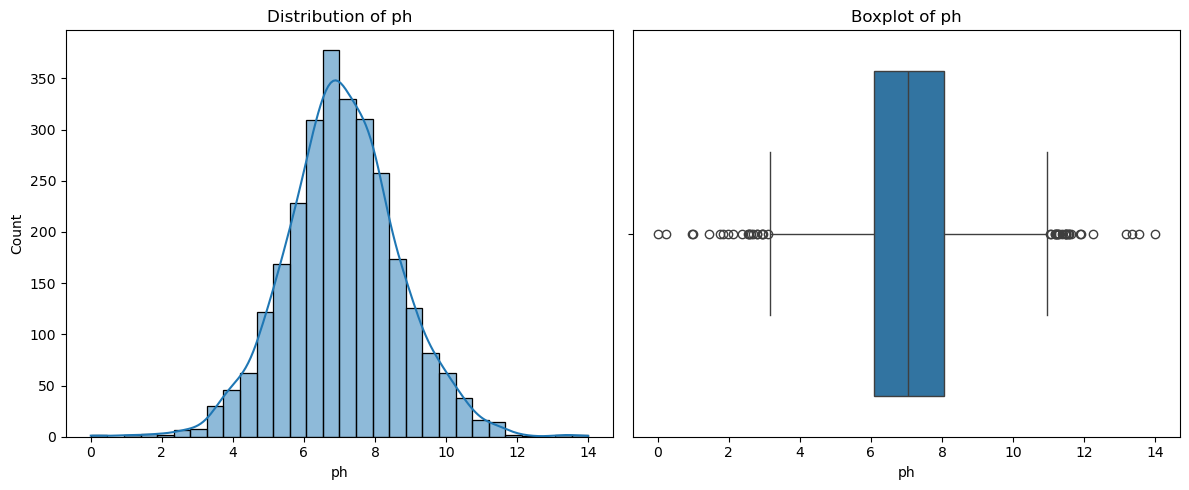

In [119]:
col = "ph"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
sns.histplot(df[col], bins=30, kde=True, ax=axes[0])
axes[0].set_title(f"Distribution of {col}")

# Boxplot
sns.boxplot(x=df[col], ax=axes[1])
axes[1].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

Distribution Plot:
1. The distribution is approximately normal (bell-shaped), centered roughly around a pH of 7.
2. Most data points cluster densely between 5 and 9.

Statistical Spread:
1. The median pH sits near 7, with the Interquartile Range (IQR) roughly spanning from 6 to 8.2.
2. Whiskers: Extend out to approximately 3 on the lower end and 11 on the upper end.
3. Outliers: Multiple individual data points appear beyond the whiskers as open circles on both extremes—specifically pointing out low outlier values near 0 to 3 and high outlier values stretching up to 14.

In [120]:
print(df.isnull().sum())
missing_pct = df['ph'].isnull().mean() * 100
print(f"Missing values: {missing_pct:.2f}%")

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64
Missing values: 14.99%


The column specifics the missing values in the dataset, with sulfate(781) having the highest count and  Trihalomethanes(162) having the lowest count and ph with 491 counts. The total missing values account exactly   14.99% of the total records

In [121]:
imputer = KNNImputer(n_neighbors=5)

df_imputed = df.copy()
df_imputed[df.columns] = imputer.fit_transform(df)

K-Nearest Neighbors (KNN) Imputation (k=5) to handle missing values across the dataset, followed by a validation check on dataset dimensions, null counts, and distribution properties for the ph feature. Rather than statistics like the mean or median, KNN imputation calculates distances through 5 clusters to fill missing values using the values of neighboring data points.


In [122]:
print(df_imputed.shape)

print(df_imputed.isnull().sum())

(3276, 10)
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [146]:
# sns.histplot(df['ph'])

In [147]:
print(df['ph'].describe())       # Original (with NaNs ignored)
print(df_imputed['ph'].describe())   # After KNN

count    2785.000000
mean        7.080795
std         1.594320
min         0.000000
25%         6.093092
50%         7.036752
75%         8.062066
max        14.000000
Name: ph, dtype: float64
count    3276.000000
mean        7.078167
std         1.497228
min         0.000000
25%         6.187017
50%         7.052221
75%         7.948570
max        14.000000
Name: ph, dtype: float64


1. The valid record count increases from 2,785 to the full dataset total of 3,276, successfully recovering the 491 missing entries with the help of KNN model. 
2. The mean remains virtually unchanged (7.081 vs. 7.078).
3. The median (50% percentile) stays stable around 7.04 to 7.05, demonstrating that the KNN imputer did not shift the central balance of the feature.
4. The standard deviation tightens slightly from 1.594 down to 1.497, which is a typical behavior of KNN imputation as estimated values tend to cluster around neighbor averages, marginally reducing extreme variance.
5. Quartiles remain tightly aligned (25% around 6.1 and 75% around 7.9–8.1), while the global minimum (0.0) and maximum (14.0) bounds are fully preserved.

In [125]:
# df = df_knn.copy()
df_with_missing_values.isna().sum()
df_imputed.isna().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [126]:
X = df.drop('Potability', axis=1)
y = df['Potability']

In [127]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

Potability
0    1998
1    1278
Name: count, dtype: int64
Potability
0    60.989011
1    39.010989
Name: proportion, dtype: float64


Non-Potable (0): Comprises 1,998 samples, representing 60.99% of the dataset.

Potable (1): Comprises 1,278 samples, representing 39.01% of the dataset.

The dataset exhibits moderate class imbalance, skewed toward non-potable water samples. This imbalance should be taken into account during model training and evaluation (e.g., using stratified splits, weighted loss functions, or evaluation metrics like F1-score and ROC-AUC rather than relying solely on raw accuracy).

In [128]:
df_final= df_imputed.copy()

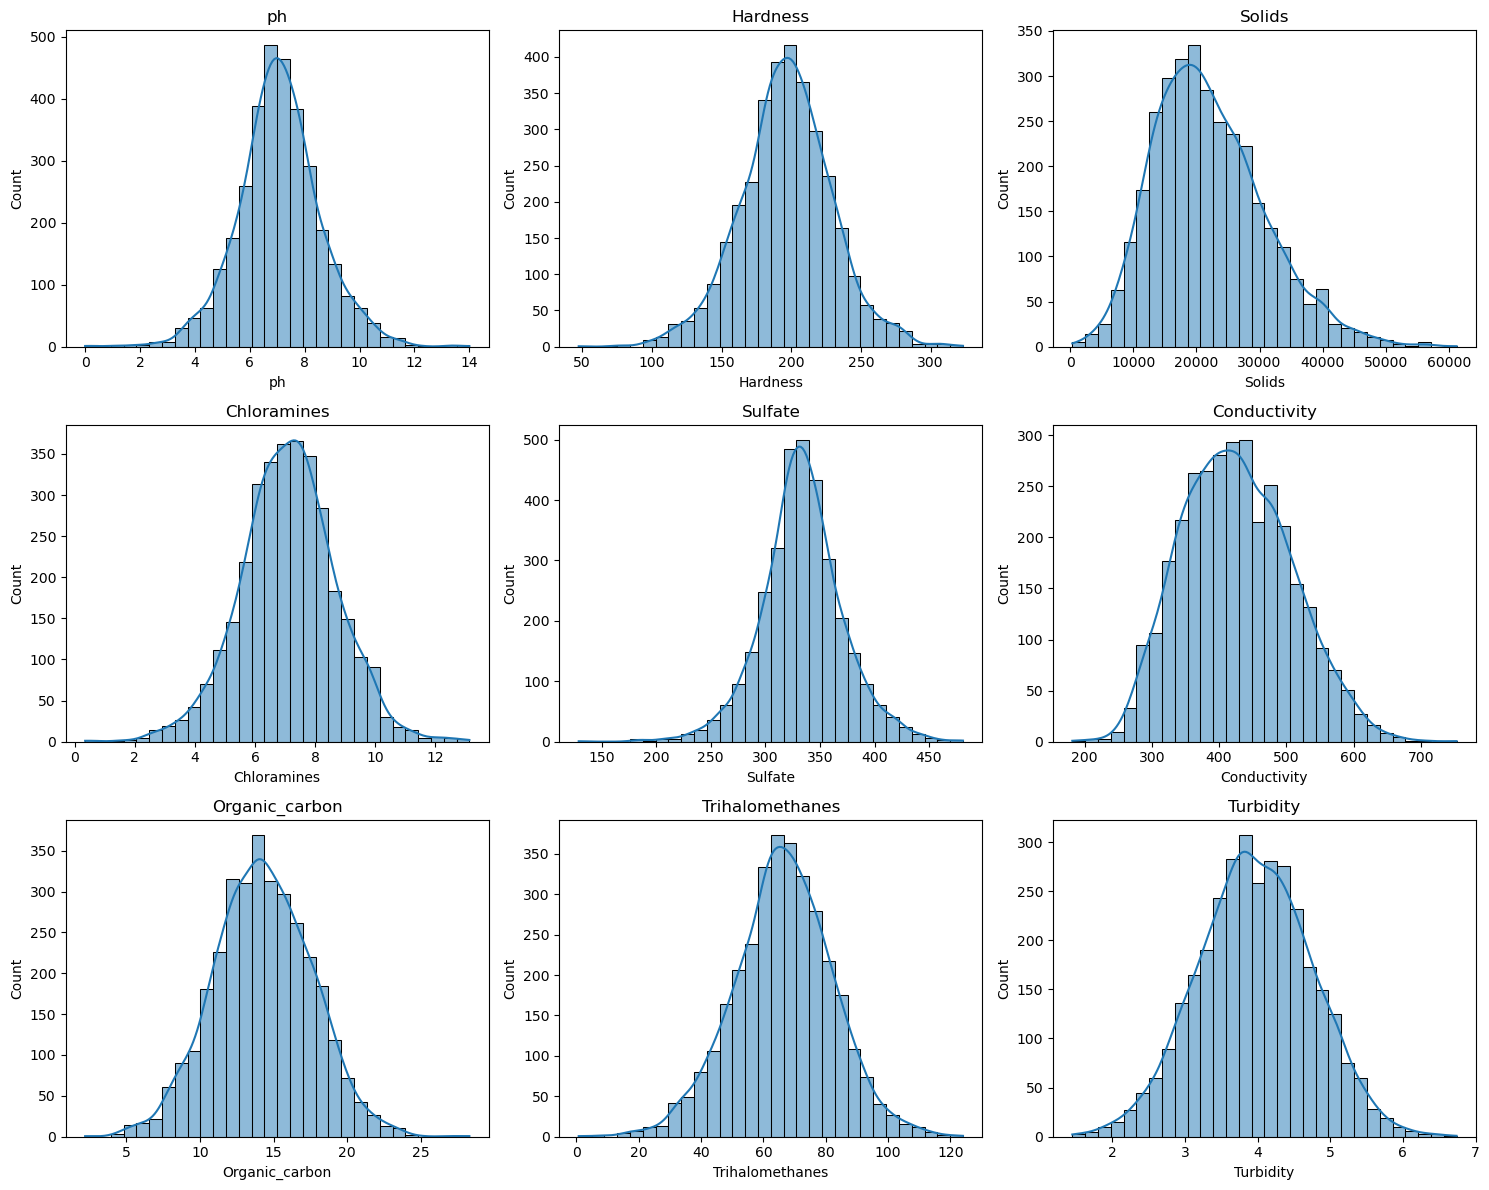

In [129]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, col in zip(axes.flatten(), X.columns):
    sns.histplot(
        df_final[col],
        kde=True,
        bins=30,
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

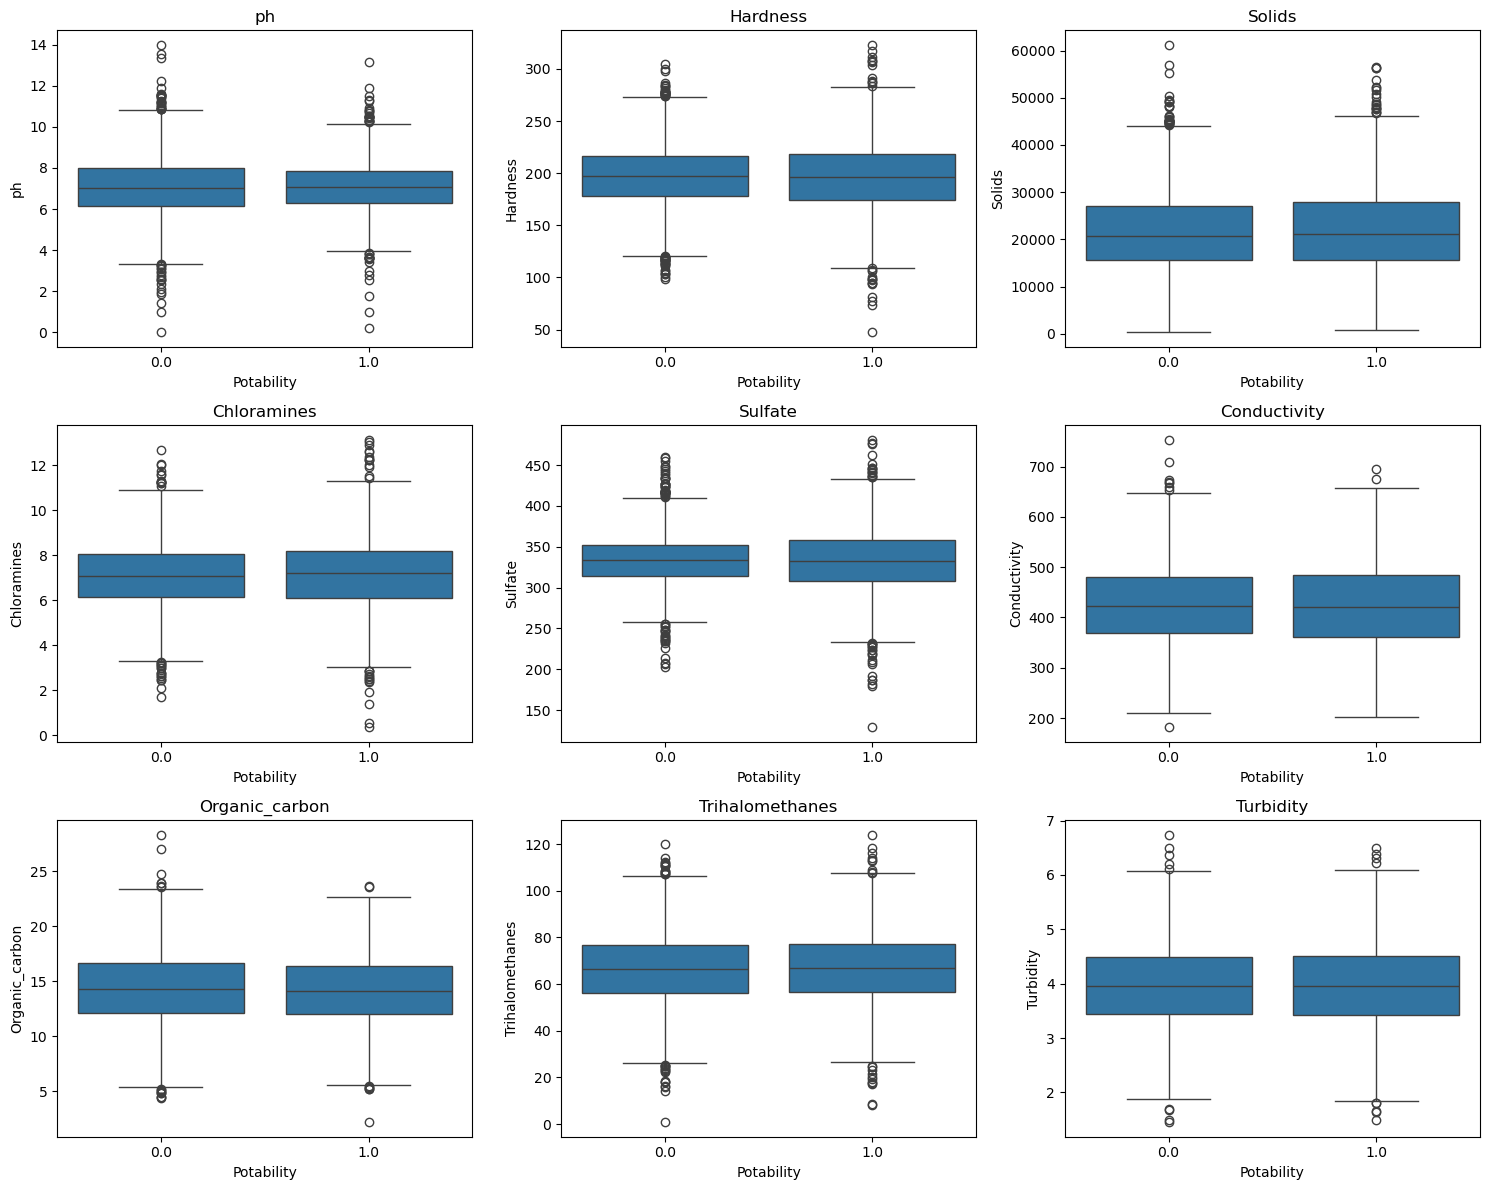

In [130]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, feature in zip(axes.flatten(), X.columns):
    sns.boxplot(
        data=df_final,
        x='Potability',
        y=feature,
        ax=ax
    )
    ax.set_title(feature)

plt.tight_layout()
plt.show()

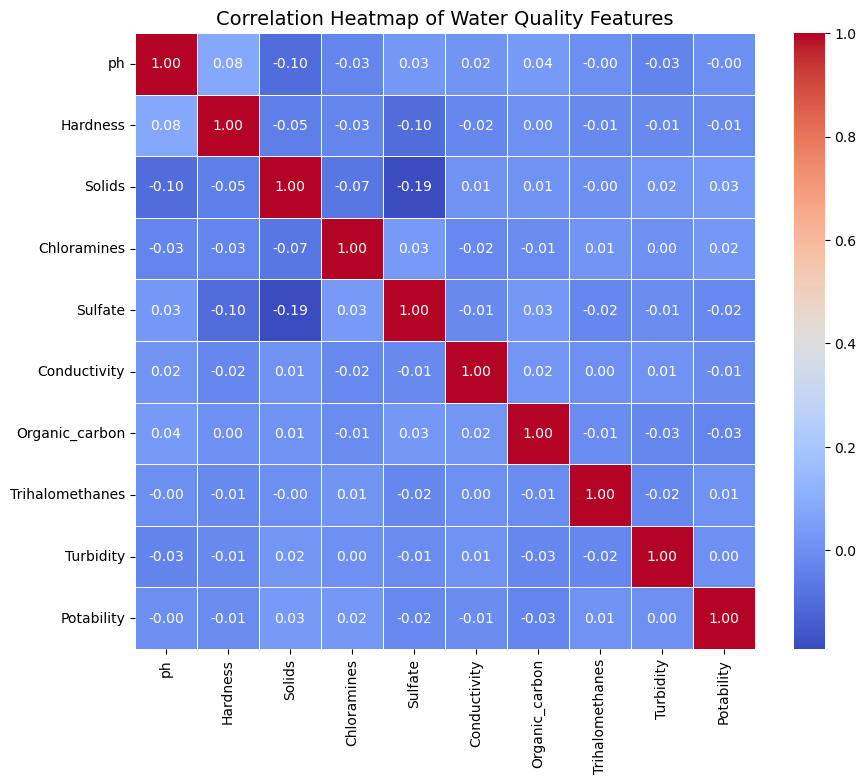

In [131]:
# Compute the correlation matrix
corr = df_final.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,      # Show correlation values
    fmt=".2f",       # Show 2 decimal places
    cmap="coolwarm", # Blue = negative, Red = positive
    linewidths=0.5
)

plt.title("Correlation Heatmap of Water Quality Features", fontsize=14)
plt.show()

Conclusion 1

No feature individually predicts potability well.

Evidence:

Boxplots overlap heavily.
Correlations with Potability are close to zero.

Conclusion 3

As Logistic Regression relies on linear relationships and the data doesnt have any, Linear models may struggle

Conclusion 4

Tree models should perform better because Random Forest doesn't need linear relationships.

It can learn things like
1. The correlation heatmap revealed very weak linear relationships among the predictor variables, as well as between the predictors and the target variable (Potability). 

2. No feature exhibited a strong correlation with water potability, indicating that no single variable alone can effectively predict the target. 

3. Additionally, no evidence of multicollinearity was observed, as correlations between predictor variables were consistently low. 

These findings suggest that machine learning models capable of capturing complex, non-linear interactions between multiple features, such as Random Forest, are likely to outperform linear models.

In [132]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

In [133]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Splits the dataset into training and testing subsets using an 80-20 ratio (`test_size=0.2`), sets a random seed (`random_state=42`) for reproducibility, and applies stratification (`stratify=y`) to ensure both sets maintain the same proportion of target classes as the original dataset.

In [134]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

Initializes a Random Forest classifier (`RandomForestClassifier`) with 200 decision trees (`n_estimators=200`) and a fixed random seed (`random_state=42`) for reproducibility, then fits the model to the training data (`X_train`, `y_train`). Later used for fined tuning the Random forest model

In [135]:
rf1 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf1.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Initializes a Random Forest classifier (`RandomForestClassifier`) using the default setting of 100 decision trees (`n_estimators=100`) and a fixed random seed (`random_state=42`) for reproducibility, then fits the model to the training data (`X_train`, `y_train`).

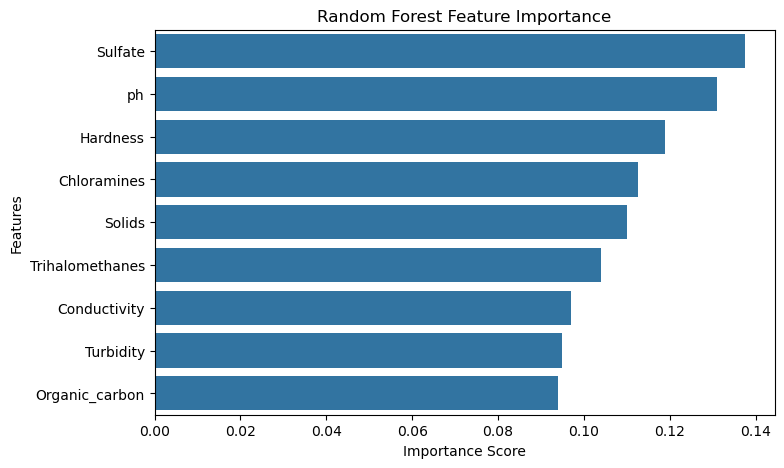

In [136]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=importance.values,
    y=importance.index
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

Although the correlation analysis showed weak linear relationships between the predictor variables and the target, the Random Forest model identified Sulfate, pH, and Hardness as the most influential features. This indicates that these variables contribute to the prediction through complex, non-linear interactions that are not captured by simple correlation analysis.

In [137]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

Sulfate            0.137522
ph                 0.131074
Hardness           0.118922
Chloramines        0.112564
Solids             0.110044
Trihalomethanes    0.104054
Conductivity       0.097113
Turbidity          0.094795
Organic_carbon     0.093912
dtype: float64


Displays the sorted feature importance scores extracted from the Random Forest model, highlighting **Sulfate** (0.138), **ph** (0.131), and **Hardness** (0.119) as the most influential predictors for water potability.

In [138]:
y_pred_rf = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.6570121951219512
Precision: 0.6324786324786325
Recall   : 0.2890625
F1 Score : 0.3967828418230563
[[357  43]
 [182  74]]
              precision    recall  f1-score   support

           0       0.66      0.89      0.76       400
           1       0.63      0.29      0.40       256

    accuracy                           0.66       656
   macro avg       0.65      0.59      0.58       656
weighted avg       0.65      0.66      0.62       656



Evaluates the performance of the trained Random Forest model (`rf`) on the test dataset by computing key classification metrics—including **Accuracy** (65.7%), **Precision** (63.2%), **Recall** (28.9%), and **F1-Score** (39.7%)—alongside a confusion matrix and full classification report.

In [139]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest F1 Score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

Best F1 Score:
0.4610535760585538


Sets up a hyperparameter tuning pipeline using `GridSearchCV` across an 81-candidate grid for the Random Forest classifier, optimizing for the **F1-score** with 5-fold cross-validation (`cv=5`) and parallel processing (`n_jobs=-1`), yielding best parameters (`max_depth=None`, `min_samples_leaf=1`, `min_samples_split=10`, `n_estimators=100`) and a cross-validated F1 score of **0.461**.

In [140]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report")
print(classification_report(y_test, y_pred_best))



Accuracy : 0.6676829268292683
Precision: 0.6461538461538462
Recall   : 0.328125
F1 Score : 0.43523316062176165

Confusion Matrix
[[354  46]
 [172  84]]

Classification Report
              precision    recall  f1-score   support

           0       0.67      0.89      0.76       400
           1       0.65      0.33      0.44       256

    accuracy                           0.67       656
   macro avg       0.66      0.61      0.60       656
weighted avg       0.66      0.67      0.64       656



Evaluates the performance of the tuned Random Forest model on the test dataset, showing improvements across key metrics—including **Accuracy** (66.8%), **Precision** (64.6%), **Recall** (32.8%), and **F1-Score** (43.5%)—alongside the updated confusion matrix and classification report.

ROC-AUC Score: 0.666


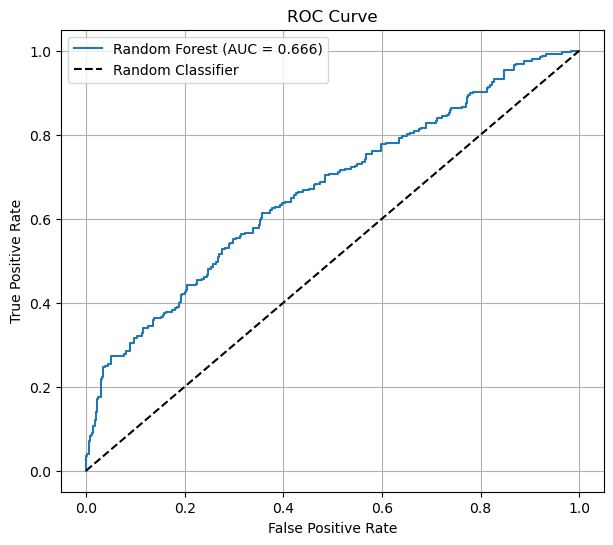

In [141]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability predictions
y_prob = best_rf.predict_proba(X_test)[:, 1]

# ROC-AUC Score
auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {auc:.3f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})")
plt.plot([0,1],[0,1],'k--',label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

Computes probability predictions from the tuned Random Forest model (`best_rf`), calculates the **ROC-AUC score** (**0.666**), and generates a Receiver Operating Characteristic (ROC) curve plot comparing the model's performance against a random classifier.

The **ROC-AUC (Receiver Operating Characteristic - Area Under Curve)** score is a key evaluation metric used to assess the performance of binary classification models. It measures the model's ability to distinguish between classes (e.g., potable vs. non-potable water).

* **ROC Curve**: A probability curve plotting the **True Positive Rate (Sensitivity)** on the y-axis against the **False Positive Rate (1 - Specificity)** on the x-axis across various classification threshold settings.
* **AUC (Area Under the Curve)**: Represents the entire two-dimensional area underneath the ROC curve from (0,0) to (1,1). It quantifies the overall ability of the model to discriminate between positive and negative classes.


* **1.0**: A perfect model that makes entirely correct classifications.
* **0.5**: Equivalent to random guessing (represented by the diagonal dashed line on the plot).
* **< 0.5**: Worse than random guessing (often indicates inverted class predictions).

The Tuned Random Forest model achieved an ROC-AUC score of **0.666**, indicating moderate discriminative power that is noticeably better than random chance, though with room for further optimization.

In [142]:
y_prob_rf = rf1.predict_proba(X_test)[:, 1]

roc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_rf)

Random Forest ROC-AUC: 0.6567333984375001


Calculates the probability predictions using the base Random Forest model (`rf1`), computes the corresponding **ROC-AUC score** (**0.657**), and prints the evaluation result to assess the model's discriminative ability prior to hyperparameter tuning.

In [143]:
y_prob_rf = rf.predict_proba(X_test)[:, 1]

roc_rf = roc_auc_score(y_test, y_prob_rf)

print("Tuned Random Forest ROC-AUC:", roc_rf)

Tuned Random Forest ROC-AUC: 0.6602978515625


In [144]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [0.6098, 0.6585, 0.6585],
    "Precision": [0.0000, 0.6356, 0.6270],
    "Recall": [0.0000, 0.2930, 0.3086],
    "F1 Score": [0.0000, 0.4011, 0.4136],
    "ROC-AUC": [
        None,      # Not calculated
        0.656,
        0.660        ,
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6098,0.0000,0.0000,0.0000,NaN
1,Random Forest,0.6585,0.6356,0.2930,0.4011,0.656
2,Tuned Random Forest,0.6585,0.6270,0.3086,0.4136,0.660


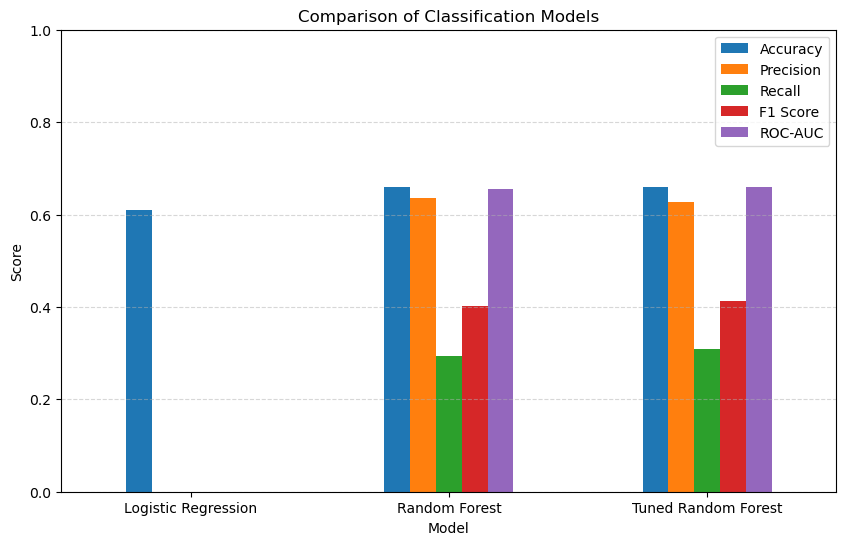

In [145]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Classification Models")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()